In [3]:
import pandas as pd

In [5]:
import numpy as np

In [7]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [11]:
visa_df=pd.read_csv(r"C:\Users\kkali\Documents\NOTES\Visadataset.csv")

In [13]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [15]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

- **Variate**  : variable

- **Bi variate** :  Two variable analysis

- **Multivariate**  : More than two variable analysis

In [19]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [43]:
con1=visa_df['case_status']=='Certified'
con2=visa_df['continent']=='Asia'
con=con1&con2
visa_df[con]
len(visa_df[con])

11012

In [51]:
certified_con=visa_df['case_status']=='Cerified'
denied_con=visa_df['case_status']=='Denied'
con=visa_df['continent']=='Asia'
certified_con=certified_con & con
denied_con=denied_con & con
len(visa_df[certified_con]),len(visa_df[denied_con])

(0, 5849)

In [71]:
labels=visa_df['continent'].value_counts().keys()
certi_count,deni_count=[],[]
for i in labels:
    certi_con=visa_df['case_status']=='Certified'
    deni_con=visa_df['case_status']=='Denied'
    con=visa_df['continent']==i
    certi_data=certi_con & con
    deni_data=deni_con & con
    certi_count.append(len(visa_df[certi_data]))
    deni_count.append(len(visa_df[deni_data]))

pd.DataFrame(zip(certi_count,deni_count),index=labels,columns=['Certified','Denied'])

,Certified,Denied
continent,,
Asia,11012,5849
Europe,2957,775
North America,2037,1255
South America,493,359
Africa,397,154
Oceania,122,70


**pd.crosstab**

In [77]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col2,col1)

<Axes: xlabel='continent'>

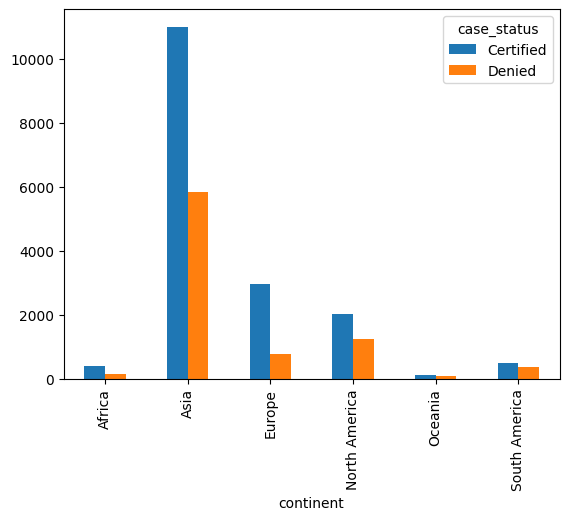

In [79]:
r1.plot(kind='bar')

array([<Axes: ylabel='Certified'>, <Axes: ylabel='Denied'>], dtype=object)

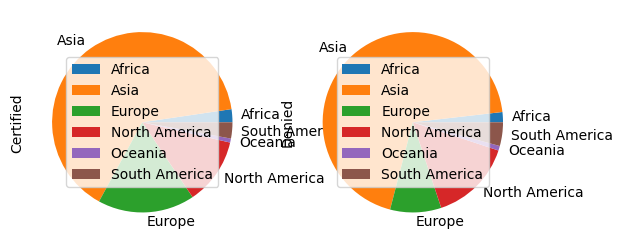

In [85]:
r1.plot(kind='pie',subplots=True)

In [87]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
Id=col2
cols=[col1,col3]
pd.crosstab(Id,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

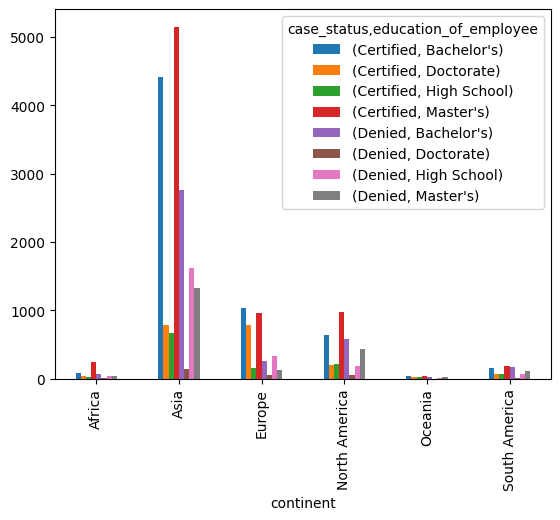

In [89]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
Id=col2
cols=[col1,col3]
r1=pd.crosstab(Id,cols)
r1.plot(kind='bar')

In [95]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
Id=col3
cols=[col1,col2]
pd.crosstab(Id,cols)

case_status           Certified                                     \
continent                Africa  Asia Europe North America Oceania   
education_of_employee                                                
Bachelor's                   81  4407   1040           641      38   
Doctorate                    43   780    788           207      19   
High School                  23   676    162           210      19   
Master's                    250  5149    967           979      46   

case_status                         Denied                                     \
continent             South America Africa  Asia Europe North America Oceania   
education_of_employee                                                           
Bachelor's                      160     62  2761    259           584      28   
Doctorate                        75     11   143     58            51       3   
High School                      74     43  1614    328           191      17   
Master's                        184     38  1331    130           429      22   

case_status                          
continent             South America  
education_of_employee                
Bachelor's                      173  
Doctorate                        14  
High School                      63  
Master's                        109

<Axes: xlabel='continent'>

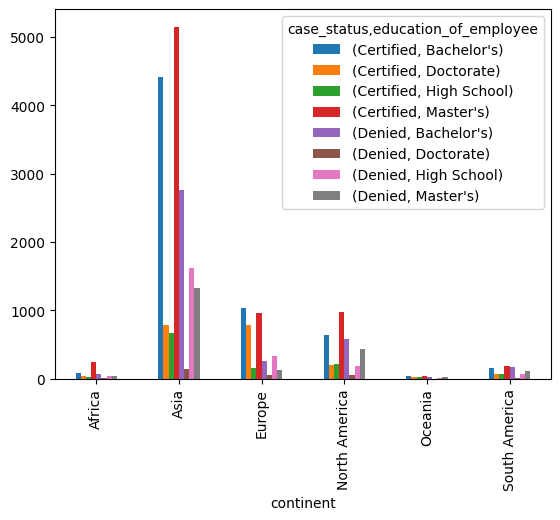

In [99]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
Id=col2
cols=[col1,col3]
r1=pd.crosstab(Id,cols)
r1.plot(kind='bar')

**Numerical column analysis**

- scatter plot

- Correlation

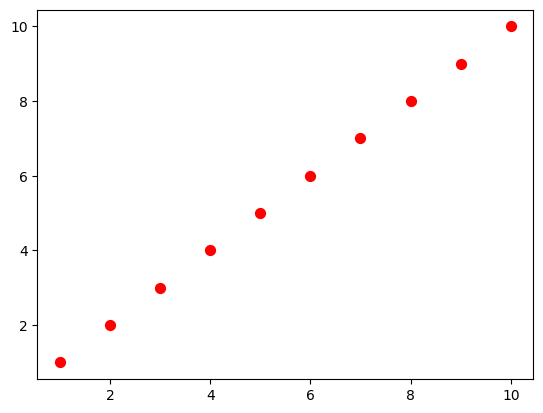

In [112]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y,c='Red',s=50)

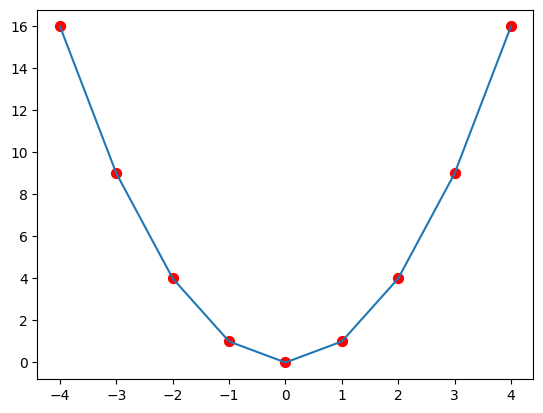

In [120]:
x=range(-4,5)
y=[i*i for i in x]
plt.scatter(x,y,c='Red',s=50)
plt.plot(x,y)

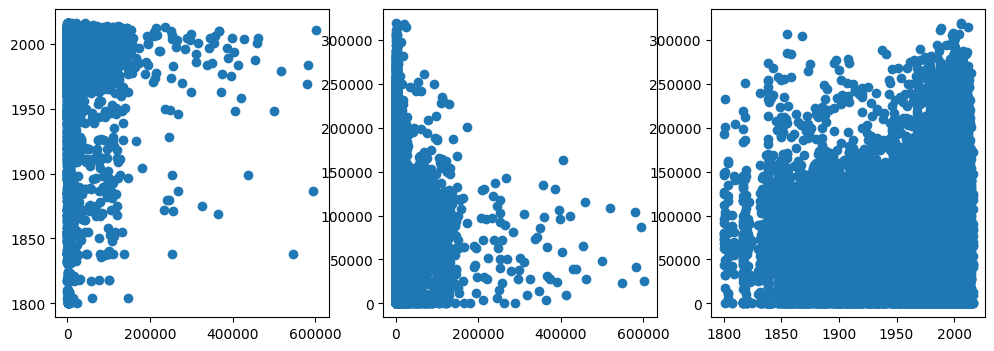

In [138]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(col1,col2)
plt.subplot(1,3,2)
plt.scatter(col1,col3)
plt.subplot(1,3,3)
plt.scatter(col2,col3)

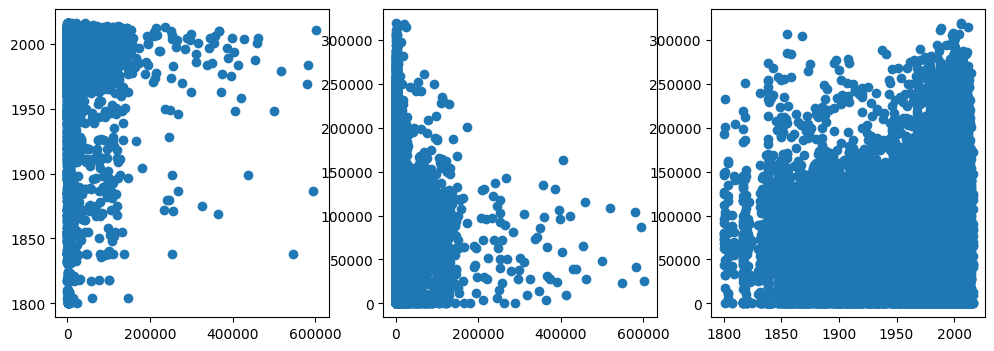

In [140]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col1,col3)
plt.subplot(1,3,3).scatter(col2,col3)

**Correlation**

In [147]:
#visa df has both numerical and categorical 
# but correlation apply only for numerical
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [157]:
wine_data=pd.read_csv(r"C:\Users\kkali\Documents\NOTES\winequality_red.csv")
wine_data.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

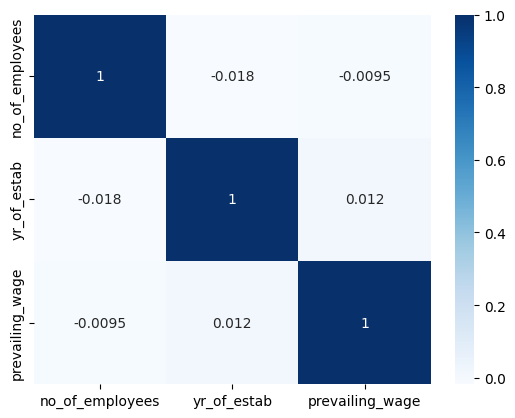

In [161]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr,annot=True,cmap='Blues')

<Axes: >

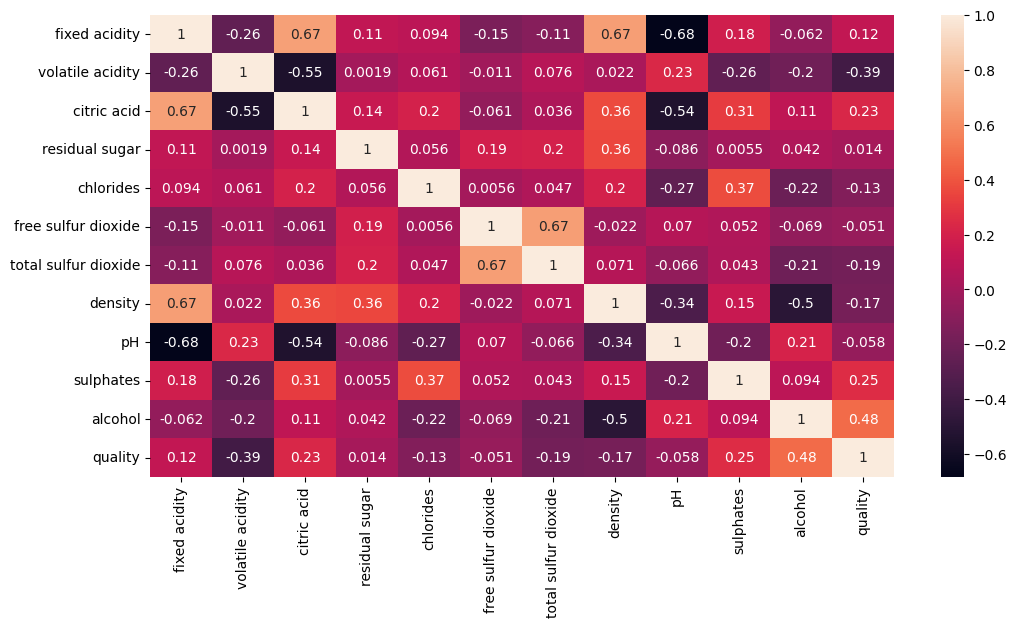

In [169]:
wine_corr=wine_data.corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(wine_corr,annot=True)

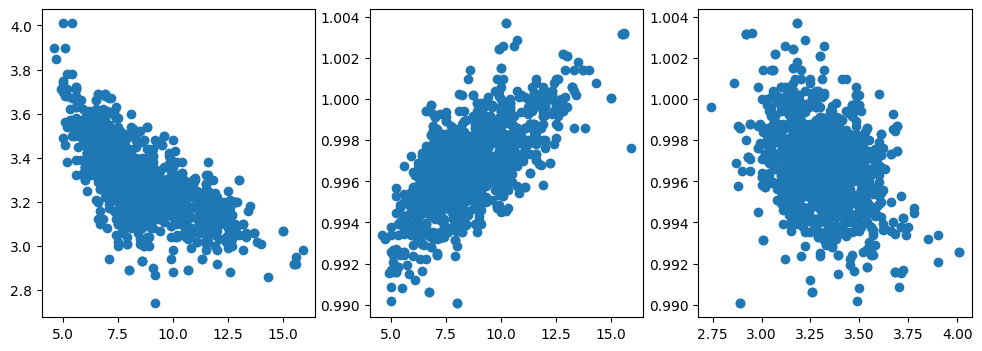

In [173]:
col1=wine_data['fixed acidity']
col2=wine_data['pH']
col3=wine_data['density']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col1,col3)
plt.subplot(1,3,3).scatter(col2,col3)

- generally we need good correlation between input and output columns

- we dont want a relation between input columns

In [188]:
pd.DataFrame(wine_corr.sort_values(by='quality',ascending=False))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919


In [190]:
wine_corr.sort_values(by='quality',ascending=False)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
